In [2]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import numpy as np
import os

def read_eval_return(log_dir, tag='eval_return'):
    """
    读取 TensorBoard 日志中的 eval_return 数据
    
    Args:
        log_dir: TensorBoard 日志目录路径
        tag: 要读取的标量标签，默认为 'eval_return'
    
    Returns:
        steps: numpy数组，步数
        values: numpy数组，对应的值
        如果读取失败，返回 None, None
    """
    try:
        ea = EventAccumulator(log_dir)
        ea.Reload()
        
        if tag not in ea.Tags()['scalars']:
            print(f"警告: 在 {log_dir} 中未找到标签 '{tag}'")
            return None, None
        
        scalar_events = ea.Scalars(tag)
        steps = np.array([s.step for s in scalar_events])
        values = np.array([s.value for s in scalar_events])
        
        return steps, values
    except Exception as e:
        print(f"读取 {log_dir} 时出错: {e}")
        return None, None

In [3]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

def plot_with_shaded_band(data_list, label='', color=None, 
                          smooth_window=10, alpha_shade=0.3, 
                          linewidth=2.0, ax=None, max_step=9e5):
    """
    绘制带阴影带的平滑曲线（用于多个seed的结果）
    只使用每个数据的前 max_step 个数据点
    
    Args:
        data_list: 数据列表，每个元素是 (steps, values) 元组
        label: 图例标签
        color: 颜色（如果不指定会自动选择）
        smooth_window: 平滑窗口大小（0表示不平滑），类似 TensorBoard 的平滑
        alpha_shade: 阴影带透明度
        linewidth: 线条宽度
        ax: matplotlib axes对象（如果要在子图中绘制）
        max_step: 最大步数，只使用 step <= max_step 的数据，默认 9e5
    """
    if len(data_list) == 0:
        print("警告: 数据列表为空")
        return None, None, None
    
    # 过滤掉None数据，并截取到max_step
    valid_data = []
    for s, v in data_list:
        if s is not None and v is not None:
            # 只保留 step <= max_step 的数据
            mask = s <= max_step
            s_filtered = s[mask]
            v_filtered = v[mask]
            if len(s_filtered) > 0:
                valid_data.append((s_filtered, v_filtered))
    
    if len(valid_data) == 0:
        print("警告: 没有有效数据")
        return None, None, None
    
    # 找到所有数据的共同范围（交集）
    min_step = max([s.min() for s, v in valid_data])
    max_step_actual = min([s.max() for s, v in valid_data])
    
    # 创建共同的step数组（只到所有数据都有的范围）
    max_num_points = max([len(s) for s, v in valid_data])
    common_steps = np.linspace(min_step, max_step_actual, max_num_points)
    
    # 将所有数据插值到共同的step范围
    interpolated_values = []
    for steps, values in valid_data:
        if len(steps) < 2:
            continue
        
        # 创建插值函数
        f = interp1d(steps, values, kind='linear', 
                     bounds_error=False, fill_value=np.nan)
        
        # 插值到共同step
        interp_values = f(common_steps)
        interpolated_values.append(interp_values)
    
    if len(interpolated_values) == 0:
        print("警告: 插值后没有有效数据")
        return None, None, None
    
    # 转换为数组
    interpolated_array = np.array(interpolated_values)
    
    # 计算均值和标准差（忽略NaN值）
    mean_values = np.nanmean(interpolated_array, axis=0)
    std_values = np.nanstd(interpolated_array, axis=0)
    
    # 找到有效数据的范围（所有曲线都有的部分）
    valid_mask = ~np.isnan(mean_values)
    common_steps_valid = common_steps[valid_mask]
    mean_values_valid = mean_values[valid_mask]
    std_values_valid = std_values[valid_mask]
    
    if len(mean_values_valid) == 0:
        print("警告: 没有有效的统计值")
        return None, None, None
    
    # 简单的移动平均平滑（类似 TensorBoard）
    if smooth_window > 0 and len(mean_values_valid) > smooth_window:
        # 使用简单的移动平均，类似 TensorBoard 的平滑方式
        smoothed_mean = np.zeros_like(mean_values_valid)
        smoothed_std = np.zeros_like(std_values_valid)
        
        for i in range(len(mean_values_valid)):
            # 取前后 smooth_window 个点的平均值
            start_idx = max(0, i - smooth_window // 2)
            end_idx = min(len(mean_values_valid), i + smooth_window // 2 + 1)
            smoothed_mean[i] = np.mean(mean_values_valid[start_idx:end_idx])
            smoothed_std[i] = np.mean(std_values_valid[start_idx:end_idx])
        
        mean_values_valid = smoothed_mean
        std_values_valid = smoothed_std
    
    # 绘制
    if ax is None:
        ax = plt.gca()
    
    # 绘制阴影带
    ax.fill_between(common_steps_valid, 
                    mean_values_valid - std_values_valid, 
                    mean_values_valid + std_values_valid,
                    alpha=alpha_shade, 
                    color=color,
                    label='_nolegend_')
    
    # 绘制均值线
    ax.plot(common_steps_valid, mean_values_valid, 
           label=label, 
           color=color,
           linewidth=linewidth)
    
    return common_steps_valid, mean_values_valid, std_values_valid

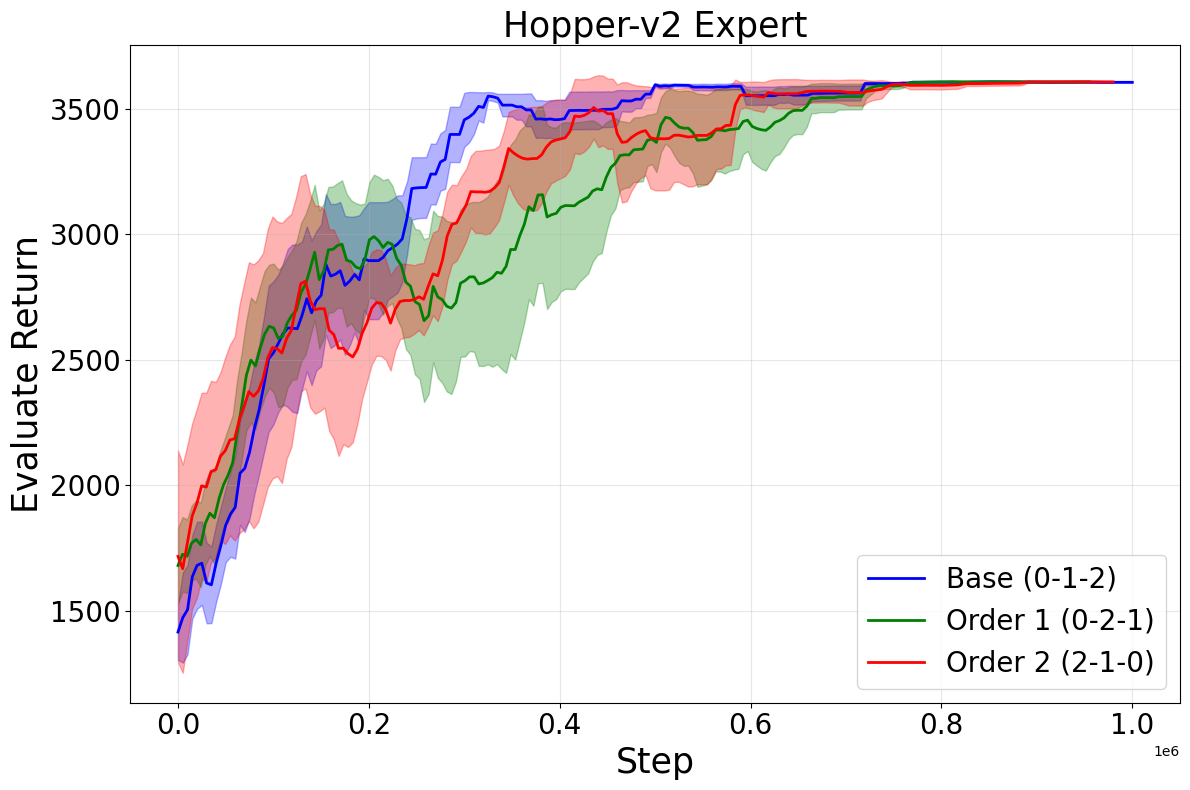

In [4]:
import matplotlib.pyplot as plt

log_base_dir = "/data/qiaodan/code/diffmarl/results/plot/order/hopper_expert"

log_list_base = ["012_1", "012_2"]
log_list_order1 = ["021_1", "021_2", "021_3"]
log_list_order2 = ["210_1", "210_2", "210_3"]


data_base=[]
data_order1=[]
data_order2=[]

for file in log_list_base:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_base.append((steps, values))

for file in log_list_order1:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_order1.append((steps, values)) 

for file in log_list_order2:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_order2.append((steps, values))




# 使用示例
plt.figure(figsize=(12, 8))

smooth_steps = 25

plot_with_shaded_band(data_base, label='Base (0-1-2)', color='blue', smooth_window=smooth_steps, max_step=1e6)
plot_with_shaded_band(data_order1, label='Order 1 (0-2-1)', color='green', smooth_window=smooth_steps, max_step=1e6)
plot_with_shaded_band(data_order2, label='Order 2 (2-1-0)', color='red', smooth_window=smooth_steps, max_step=1e6)

plt.xlabel('Step', fontsize=25)
plt.ylabel('Evaluate Return', fontsize=25)
plt.title('Hopper-v2 Expert', fontsize=25)
plt.legend(fontsize=20, loc='best')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()



save_dir = "/data/qiaodan/code/diffmarl/results/plot/order"
plt.savefig(os.path.join(save_dir, 'hopper_expert_order.png'), dpi=300, bbox_inches='tight')

plt.show()

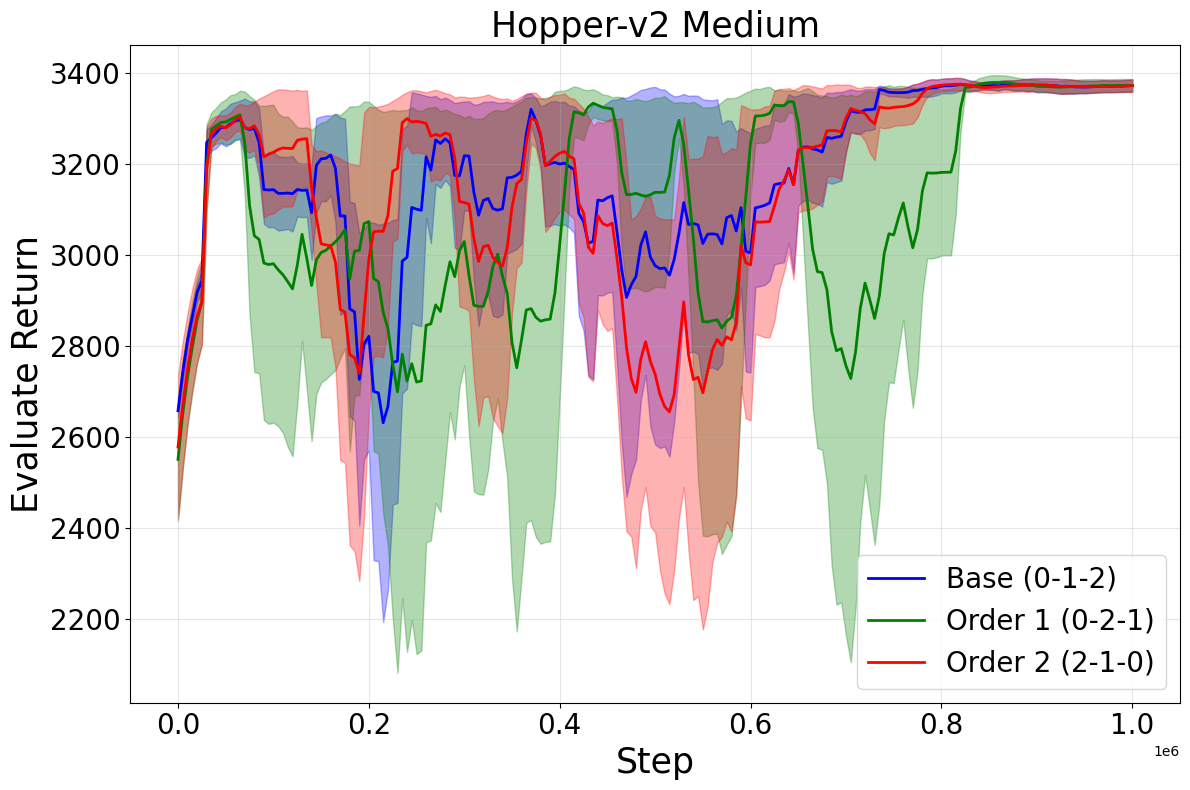

In [22]:
# medium


log_base_dir = "/data/qiaodan/code/diffmarl/results/plot/order/hopper_medium"

# log_list_base = ["012_1", "012_2"]
# log_list_order1 = ["021_1", "021_2"]
# log_list_order2 = ["210_1"]

log_list_base = ["012_1", "012_2"]
log_list_order1 = ["021_1", "012_1"]
log_list_order2 = ["210_1", "012_2"]


data_base=[]
data_order1=[]
data_order2=[]

for file in log_list_base:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_base.append((steps, values))

for file in log_list_order1:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_order1.append((steps, values)) 

for file in log_list_order2:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_order2.append((steps, values))




# 使用示例
plt.figure(figsize=(12, 8))

smooth_steps = 11

plot_with_shaded_band(data_base, label='Base (0-1-2)', color='blue', smooth_window=smooth_steps, max_step=1e6)
plot_with_shaded_band(data_order1, label='Order 1 (0-2-1)', color='green', smooth_window=smooth_steps, max_step=1e6)
plot_with_shaded_band(data_order2, label='Order 2 (2-1-0)', color='red', smooth_window=smooth_steps, max_step=1e6)

plt.xlabel('Step', fontsize=25)
plt.ylabel('Evaluate Return', fontsize=25)
plt.title('Hopper-v2 Medium', fontsize=25)
plt.legend(fontsize=20, loc='best')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()



save_dir = "/data/qiaodan/code/diffmarl/results/plot/order"
plt.savefig(os.path.join(save_dir, 'hopper_medium_order.png'), dpi=300, bbox_inches='tight')

plt.show()

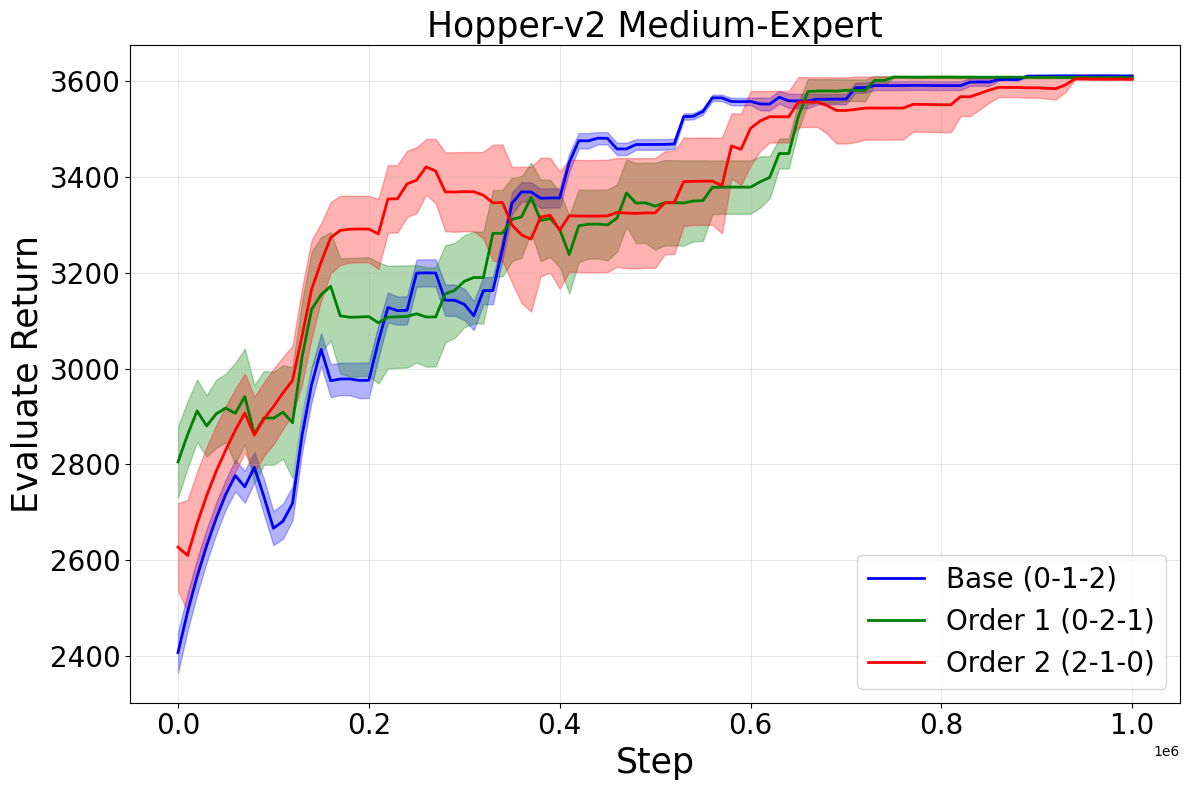

In [23]:
# medium-expert


log_base_dir = "/data/qiaodan/code/diffmarl/results/plot/order/hopper_medium_expert"

# log_list_base = ["012_1", "012_2"]
# log_list_order1 = ["021_1", "021_2"]
# log_list_order2 = ["210_1"]

log_list_base = ["012_1", "012_2"]
log_list_order1 = ["021_1", "021_2"]
log_list_order2 = ["210_1", "210_2"]


data_base=[]
data_order1=[]
data_order2=[]

for file in log_list_base:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_base.append((steps, values))

for file in log_list_order1:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_order1.append((steps, values)) 

for file in log_list_order2:
    log_dir = os.path.join(log_base_dir, file)
    steps, values = read_eval_return(log_dir)
    data_order2.append((steps, values))




# 使用示例
plt.figure(figsize=(12, 8))

smooth_steps = 25

plot_with_shaded_band(data_base, label='Base (0-1-2)', color='blue', smooth_window=smooth_steps, max_step=1e6)
plot_with_shaded_band(data_order1, label='Order 1 (0-2-1)', color='green', smooth_window=smooth_steps, max_step=1e6)
plot_with_shaded_band(data_order2, label='Order 2 (2-1-0)', color='red', smooth_window=smooth_steps, max_step=1e6)

plt.xlabel('Step', fontsize=25)
plt.ylabel('Evaluate Return', fontsize=25)
plt.title('Hopper-v2 Medium-Expert', fontsize=25)
plt.legend(fontsize=20, loc='best')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()



save_dir = "/data/qiaodan/code/diffmarl/results/plot/order"
plt.savefig(os.path.join(save_dir, 'hopper_medium_expert_order.png'), dpi=300, bbox_inches='tight')

plt.show()